# Week 4 — Policy Uncertainty Analysis
Standalone notebook. Reads Week 3 disk outputs; never re-runs rolling GARCH/VAR.

**Markets processed in isolation:** China (benchmark) → US (comparison).  
Comparison occurs only in Stage C (cross-market interpretation).

**Required disk inputs per market** (`outputs/{market}/`):
- `rolling_tsi.csv` — index: `date`, column: `TSI` (+ `NET_*`, `TO_*`, `FROM_*`)
- `garch_volatility_panel.csv` — daily conditional σ, columns = GICS sector names

**New raw data** (`data/{market}/`):
- EPU file — Economic Policy Uncertainty index, monthly (filename/columns per `MARKET_CONFIGS`)
- TPU file — Trade Policy Uncertainty index, monthly (filename/columns per `MARKET_CONFIGS`)

File names and column schemas are fully specified in `MARKET_CONFIGS` — no hardcoded globals.

## 0.0 — Setup

Run this in terminal before importing:

```bash
pip install numpy ipykernel
pip install pandas ipykernel
pip install statsmodels ipykernel
pip install arch ipykernel
pip install openpyxl
pip install matplotlib 
pip install seaborn
```

In [ ]:
import warnings, logging
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore')

# `logging` — every decision the pipeline makes (which lag order, 
# which rows were dropped) is written to a timestamped log, not just printed. 
# This creates a reproducible audit trail.
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s  %(levelname)-8s  %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S',
)
log = logging.getLogger(__name__)

In [3]:
BASE_DIR    = Path().resolve()
DATA_DIR    = BASE_DIR / 'data'
OUTPUTS_DIR = BASE_DIR / 'outputs'
LOGS_DIR    = BASE_DIR / 'logs'
ISSUE_LOG   = LOGS_DIR / 'issue_log.txt'
for d in [OUTPUTS_DIR, LOGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Hyperparameters (inherited from Week 3 where shared) ──────────────────────
ADF_MAXLAG   = 12
ADF_PVAL_THR = 0.05
HORIZON      = 10       # GFEVD forecast horizon
IRF_REPS     = 1000     # bootstrap replications for IRF CIs
IRF_HORIZON  = 12       # months ahead for Route 1 IRF
FDR_ALPHA    = 0.05     # Benjamini-Hochberg FDR level

# ── Market registry — indicator-level configuration ───────────────────────────
# epu_sheet / tpu_sheet: int → single sheet, list[int] → multi-sheet (concat),
#                         str → sheet by name.
# is_split_date: True  → year/month columns,  False → unified date column.
MARKETS = ['china', 'us']

MARKET_CONFIGS = {
    'china': {
        'epu': {
            'epu_file':      'China_EPU.xlsx',
            'epu_sheet':     [0, 1, 2],           # multi-sheet → row-wise mean
            'epu_col':       'EPU',
            'is_split_date': True,
            'epu_year_col':  'year',
            'epu_month_col': 'month',
        },
        'tpu': {
            'tpu_file':      'China_Mainland_Paper_TPU.xlsx',
            'tpu_sheet':     3,
            'tpu_col':       'TPU',
            'is_split_date': True,
            'tpu_year_col':  'year',
            'tpu_month_col': 'month',
        },
    },
    'us': {
        'epu': {
            'epu_file':      'US_EPU.xlsx',
            'epu_sheet':     0,
            'epu_col':       'News_Based_Policy_Uncert_Index',
            'is_split_date': True,
            'epu_year_col':  'Year',
            'epu_month_col': 'Month',
        },
        'tpu': {
            'tpu_file':      'US_TPU.xlsx',
            'tpu_sheet':     2,
            'tpu_col':       'TPU',
            'is_split_date': False,
            'date_col':      'DATE',
        },
    },
}

GICS_SECTORS = [
    'Energy', 'Materials', 'Industrials',
    'Consumer Discretionary', 'Consumer Staples', 'Health Care',
    'Financials', 'Information Technology', 'Communication Services',
    'Utilities', 'Real Estate',
]

log.info('Configuration loaded. Markets: %s', MARKETS)

2026-06-27 21:06:05  INFO      Configuration loaded. Markets: ['china', 'us']


## 1.0 Shared Functions

4 tools the entire pipeline depends on:

---

#### <span style="color:#63C2FF">_log_issue(market, context, message)</span>

**Flow:** Error event → append timestamped entry to `logs/issue_log.txt` → also emit as a `WARNING` in the console.

**Why:** Silent failures ruin reproducible research. Rather than letting a minor data anomaly kill the whole notebook, it is logged, the pipeline continues, and you can review all anomalies in one place after the run.

---

#### <span style="color:#63C2FF">adf_test(series)</span>

**Flow:** A time series → Augmented Dickey-Fuller test → `(is_stationary: bool, p_value: float)`.

**Why this matters (econometrics):** A VAR model assumes that all variables are ***stationary, i.e. their average and variance don't drift over time***. If you feed a "wandering" series (like a price level) into a VAR, the model's coefficient estimates become meaningless (a classic problem called spurious/false regression). The ADF test is the 1st line of defence that catches this.

**Key logic:**
- `autolag='AIC'`: 

    the test automatically selects how many lagged differences to include in its own internal regression, using the Akaike Information Criterion.

- `regression='c'`: 

    includes a constant (intercept) but not a time trend, appropriate for economic indexes that don't have a deterministic upward drift.

- The `< 20` row guard prevents the test from running on samples too small to be reliable.

---

#### <span style="color:#63C2FF">log_diff(series)</span>

**Flow:** A levels series (e.g., EPU index value) → `ln(Pₜ) − ln(Pₜ₋₁)` → a percent-change series with the leading NaN dropped.

**Why:** Log-differencing is the standard transformation to make a policy index stationary. It converts "the EPU index was 120 this month" into "EPU grew by 3.2% this month". The `<= 0` guard exists because `log(0)` and `log(negative)` are mathematically undefined, such values are converted to NaN and dropped before this function is called.

---

#### <span style="color:#63C2FF">make_stationary(series, market, label)</span>

**Flow:** Any series → ADF test → if stationary, return as-is. if not, log-difference it and re-test → return the stationary version with a new label.

**Why:** TCI and sector volatility are tested empirically rather than log-differenced by default, because conditional variance series from GARCH models sometimes already revert to a mean and pass the ADF test at levels. This function applies the minimum necessary transformation and documents which path was taken.

---

#### <span style="color:#63C2FF">compute_gfevd(var_res, H) + row_norm(theta) + directional_measures(th_star, names)</span>

**Flow:** A fitted VAR model → simulate how a one-unit shock to variable j explains the forecast error of variable i at horizons 0…H → normalise rows to sum to 100% → compute TO / FROM / NET spillover scores per node.

**Why (econometrics):** This is the Pesaran-Shin (1998) Generalised Forecast Error Variance Decomposition (GFEVD). Unlike the traditional Cholesky decomposition, ***GFEVD does not depend on the order you list your variables***, i.e. the result is the same regardless of whether you put EPU or TCI first. This order-invariance is essential when you have no strong prior about which sector/variable comes first.

**Key logic:**
- `A[h, i, :]`:

    the impulse response matrix at horizon h. it shows how all variables respond to a shock initiated at step 0.

- $\sigma$ (sigma_u): 

    the covariance matrix of the VAR's residuals. captures how the shocks to different variables are correlated with each other.

- `row_norm`: 

    after GFEVD, each row does not necessarily sum to 100% because shocks are correlated. Row-normalisation forces the shares to sum to 1 so they are interpretable as percentages.

- `NET = TO − FROM`: 

    +ve NET means a node is a net transmitter of risk to others, -ve means it absorbs more than it sends.

---

#### <span style="color:#63C2FF">bh_correct(p_values, alpha=0.05)</span>

**Flow:** Array of p-values from multiple hypothesis tests → apply Benjamini-Hochberg ranking → return a boolean array marking which tests survive after controlling the false-discovery rate.

**Why:** When you run Granger causality tests at 12 different lag lengths, you are running 12 separate hypothesis tests. By chance alone, roughly 5% of them will appear "significant" even if there is no real relationship (false positives). BH correction controls the expected proportion of false discoveries among all rejected hypotheses, which is less conservative than Bonferroni (which controls the probability of even one false positive).

**Key logic:**
- Hypotheses are ranked by p-value, smallest first.
- Each hypothesis's threshold is `(rank / total_tests) × alpha`
- All hypotheses up to and including the last one that passes its threshold are rejected together (`k_max` logic).

In [ ]:
def _log_issue(market, context, message):
    ts    = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    entry = f'[{ts}] [{market.upper()}] [{context}] {message}\n'
    with open(ISSUE_LOG, 'a') as fh:
        fh.write(entry)
    log.warning(entry.strip())


def adf_test(series, maxlag=ADF_MAXLAG, pval_thr=ADF_PVAL_THR):
    """Return (stationary: bool, p_value: float)."""
    s = series.dropna()
    if len(s) < 20:
        return False, np.nan
    stat, pval, *_ = adfuller(s, maxlag=maxlag, autolag='AIC', regression='c')
    return pval < pval_thr, round(pval, 6)


def log_diff(series):
    """Log-first-difference a monthly Series; drops the leading NaN."""
    if (series <= 0).any():
        raise ValueError(f'Non-positive values in series {series.name!r}; cannot log-transform.')
    return np.log(series).diff(1).dropna()


def make_stationary(series, market, label):
    """ADF-gate: return level if stationary, log-diff otherwise. Logs decision."""
    stat, pval = adf_test(series)
    if stat:
        log.info('[%s] %s stationary at level (ADF p=%.4f) → using level', market, label, pval)
        return series, label, pval
    log.info('[%s] %s non-stationary (ADF p=%.4f) → log-differencing', market, label, pval)
    diff = log_diff(series)
    stat2, pval2 = adf_test(diff)
    if not stat2:
        _log_issue(market, 'ADF', f'{label} still non-stationary after log-diff (p={pval2:.4f})')
    return diff, f'Δln_{label}', pval2


# ── GFEVD (Pesaran-Shin 1998, order-invariant) ────────────────────────────────
# Exact implementation carried over from Week 3 (compute_gfevd / row_norm /
# directional_measures) to guarantee consistent results in Route 2.

def compute_gfevd(var_res, H):
    A   = np.asarray(var_res.irf(periods=H).irfs)   # (H, n, n) — use first H terms
    Sig = np.asarray(var_res.sigma_u)
    n   = Sig.shape[0]
    sig_diag = np.diag(Sig)
    theta = np.zeros((n, n))
    for i in range(n):
        denom = sum(A[h, i, :] @ Sig @ A[h, i, :].T for h in range(H))      # changed "H + 1" to H
        for j in range(n):
            numer = (1. / sig_diag[j]) * sum(
                (A[h, i, :] @ Sig[:, j]) ** 2 for h in range(H)             # changed "H + 1" to H
            )
            theta[i, j] = numer / denom if denom > 1e-10 else 0.
    return theta


def row_norm(theta):
    rs = theta.sum(axis=1, keepdims=True)
    return theta / np.where(rs == 0, 1., rs)


def directional_measures(th_star, names):
    off = th_star.copy()
    np.fill_diagonal(off, 0.)
    TO   = off.sum(axis=0)
    FROM = off.sum(axis=1)
    NET  = TO - FROM
    OWN  = np.diag(th_star)
    tsi  = off.sum() / len(names) * 100
    df   = pd.DataFrame(
        {'TO': TO * 100, 'FROM': FROM * 100, 'NET': NET * 100, 'OWN': OWN * 100},
        index=names,
    ).round(4)
    return df, tsi


# ── Benjamini-Hochberg FDR correction ─────────────────────────────────────────
def bh_correct(p_values, alpha=FDR_ALPHA):
    """Return array of booleans: True where H0 is rejected after BH correction."""
    p = np.asarray(p_values, dtype=float)
    m = len(p)
    if m == 0:
        return np.array([], dtype=bool)
    ranks  = np.argsort(p) + 1          # rank 1 = smallest p
    order  = np.argsort(p)
    thresholds = (ranks / m) * alpha
    # Find largest rank k where p_(k) <= (k/m)*alpha
    below  = p[order] <= thresholds
    if not below.any():
        return np.zeros(m, dtype=bool)
    k_max  = np.where(below)[0].max()
    reject = np.zeros(m, dtype=bool)
    reject[order[:k_max + 1]] = True
    return reject

## 2.0 Policy indicator loaders

#### <span style="color:#63C2FF">parse_dates(df, cfg)</span>

**Flow:** Raw DataFrame + config dict → DatetimeIndex normalised to the first day of each month.

**Why date normalisation matters:** TCI and sector volatility will later be aggregated to monthly frequency using `.to_period('M').to_timestamp()`, which always produces the first day of the month. If EPU dates land on the 15th or end-of-month, the subsequent `pd.concat` merge will find no matching keys and silently produce an empty DataFrame. Normalising everything to month-start ***prevents this misalignment***.

**Key logic:**
- `is_split_date: True` path:

  constructs the date from integer year and month columns using `pd.to_datetime({'year':..., 'month':..., 'day': 1})`. This handles source files where the date is stored separatedly as Year and Monthly columns.

- `is_split_date: False` path:

  parses a string date column then normalises via `.dt.to_period('M').dt.to_timestamp()`. The two-step conversion ensures that dates like `"2021-03-15"` and `"2021-03-01"` both land on `2021-03-01`.

---

#### <span style="color:#63C2FF">load_and_parse_indicator(mkt, indicator_type)</span>

**Flow:** Market ID + indicator type (`'epu'` or `'tpu'`) → look up `MARKET_CONFIGS` → read file → parse dates → sanitise values → return a clean monthly Series.

**Why this matters:** China EPU is published as three separate sub-indexes across three Excel sheets (news, soft data, financial). Averaging them into a single composite before any further transformation is methodologically consistent with Baker et al.'s original construction. Handling this inside the loader keeps `prepare_market_data()` clean and unaware of source-level complexity.

**Key logic:**
- `isinstance(sheet_key, list)` branch:

  `pd.read_excel` with a list of sheet indices returns a `dict {sheet_index: DataFrame}`. The loop iterates that dict, calls `parse_dates` on each sheet independently, and collects Series into a list before taking `.mean(axis=1)`. This means if Sheet 1 has data for 2008-01 and Sheet 2 does not, the mean is still computed on the overlapping months only.

- `pd.to_numeric(..., errors='coerce')`:

  deals with the footer cells containing source references by converting them to `NaN` to avoid errors.

- **Non-positive sanitisation block**:

  - `result.mask(result <= 0)`:

    replaces every 0 or -ve value with `NaN` without touching genuine `NaN`s already present.

  - `.dropna()`:
  
  removes all `NaN` rows in a single pass (original + newly masked).

  - `_log_issue()` call: 
  
    records exactly how many rows were dropped and what the minimum surviving value is. critical for methods section for data quality checking.

  - The empty-series guard at the end ensures a corrupt file fails loudly with a clear error message pointing to the exact `MARKET_CONFIGS` key, rather than failing silently 200 lines later inside the VAR.

- **Why clean here, not later?**

  `log_diff()` calls `np.log()`, which will throw a `ValueError` on any value ≤ 0. More critically, if you forward-filled to daily frequency first and then cleaned, a single bad monthly value would silently corrupt ~20 daily rows before being caught.

In [4]:
def parse_dates(df, cfg):
    """
    Build a DatetimeIndex from a raw DataFrame using cfg metadata.

    Parameters
    ----------
    df  : pd.DataFrame  — raw sheet content, columns already lowered if needed.
    cfg : dict          — indicator sub-dict from MARKET_CONFIGS[mkt]['epu'|'tpu'].

    Returns
    -------
    pd.DatetimeIndex aligned to month-start (day=1).
    """
    if cfg.get('is_split_date', False):
        # Determine year/month column names: epu_year_col / tpu_year_col both work
        year_col  = cfg.get('epu_year_col') or cfg.get('tpu_year_col')
        month_col = cfg.get('epu_month_col') or cfg.get('tpu_month_col')
        
        # Force numeric validation to identify footer text rows
        valid_mask = pd.to_numeric(df[year_col], errors='coerce').notna() & \
                     pd.to_numeric(df[month_col], errors='coerce').notna()
        
        # Drop invalid metadata/footer rows in-place so df stays aligned everywhere
        invalid_idx = df.index[~valid_mask]
        if len(invalid_idx) > 0:
            df.drop(index=invalid_idx, inplace=True)
            
        dates = pd.to_datetime({
            'year':  df[year_col].astype(int),
            'month': df[month_col].astype(int),
            'day':   1,
        })
    else:
        # Validate unified date columns
        valid_mask = pd.to_datetime(df[cfg['date_col']], errors='coerce').notna()
        
        invalid_idx = df.index[~valid_mask]
        if len(invalid_idx) > 0:
            df.drop(index=invalid_idx, inplace=True)
            
        dates = pd.to_datetime(df[cfg['date_col']])
        dates = dates.dt.to_period('M').dt.to_timestamp()   # normalise to month-start

    return dates


def load_and_parse_indicator(mkt, indicator_type):
    """
    Load one policy indicator (EPU or TPU) for a given market.

    Handles:
    - CSV and XLSX files transparently (extension-detected).
    - Single sheet (int or str) → one DataFrame.
    - Multi-sheet list[int] → dict of DataFrames → row-wise mean across sheets.
    - Split year/month date columns and unified date columns.

    Parameters
    ----------
    mkt            : str  — market key ('china' | 'us').
    indicator_type : str  — 'epu' or 'tpu'.

    Returns
    -------
    pd.Series  — monthly, DatetimeIndex (month-start), name = 'EPU' or 'TPU'.
    """
    cfg          = MARKET_CONFIGS[mkt][indicator_type]
    target_col   = cfg.get('epu_col') or cfg.get('tpu_col')
    out_name     = indicator_type.upper()             # 'EPU' or 'TPU'
    sheet_key    = cfg.get('epu_sheet') if indicator_type == 'epu' else cfg.get('tpu_sheet')
    file_key     = cfg.get('epu_file')  if indicator_type == 'epu' else cfg.get('tpu_file')

    dat_m = DATA_DIR / mkt
    fpath = dat_m / file_key
    if not fpath.exists():
        raise FileNotFoundError(f'[{mkt.upper()}] Missing {indicator_type.upper()} file: {fpath}')

    ext = fpath.suffix.lower()

    # ── Read raw data ──────────────────────────────────────────────────────────
    if ext in ('.xlsx', '.xls'):
        if isinstance(sheet_key, list):
            # Multi-sheet: pd.read_excel returns dict {sheet_index: DataFrame}
            raw = pd.read_excel(fpath, sheet_name=sheet_key, header=0)
            series_list = []
            for sheet_idx, df in raw.items():
                if target_col not in df.columns:
                    _log_issue(mkt, f'{out_name}_LOAD',
                               f'Sheet {sheet_idx}: column "{target_col}" missing — skipped')
                    continue
                dates = parse_dates(df, cfg)
                s = pd.Series(
                    pd.to_numeric(df[target_col], errors='coerce').values,
                    index=dates,
                    name=out_name,
                )
                series_list.append(s)
            if not series_list:
                raise ValueError(f'[{mkt.upper()}] No valid sheets found for {out_name}.')
            # Align on union index, take row-wise mean across sheets
            master_df = pd.concat(series_list, axis=1)
            result    = master_df.mean(axis=1).rename(out_name)
            log.info('[%s] %s loaded from %d sheets → %d rows after mean',
                     mkt.upper(), out_name, len(series_list), len(result))
        else:
            df     = pd.read_excel(fpath, sheet_name=sheet_key, header=0)
            dates  = parse_dates(df, cfg)
            result = pd.Series(
                pd.to_numeric(df[target_col], errors='coerce').values,
                index=dates,
                name=out_name,
            )
            log.info('[%s] %s loaded from sheet %s → %d rows',
                     mkt.upper(), out_name, sheet_key, len(result))
    else:
        # CSV: sheet_key is ignored
        df     = pd.read_csv(fpath)
        if target_col not in df.columns:
            raise KeyError(
                f'[{mkt.upper()}] {out_name} column "{target_col}" not in {file_key}. '
                f'Available: {list(df.columns)}'
            )
        dates  = parse_dates(df, cfg)
        result = pd.Series(
            pd.to_numeric(df[target_col], errors='coerce').values,
            index=dates,
            name=out_name,
        )
        log.info('[%s] %s loaded from CSV → %d rows', mkt.upper(), out_name, len(result))

    # ── Clean: normalise index to month-start, sort, dedup ────────────────────
    result.index = pd.to_datetime(result.index).to_period('M').to_timestamp()
    result.index.name = 'date'
    result = result.sort_index()
    result = result[~result.index.duplicated(keep='last')]

    # ── Sanitise non-positive values BEFORE any downstream log/ffill ──────────
    # Zeroes and negatives in policy indexes are data artefacts (placeholders,
    # publication gaps, or mis-encoded missing values). Masking them here
    # prevents log_diff() from raising ValueError and stops ffill() from
    # propagating bad values across the daily timeline.
    n_total   = len(result)
    n_nonpos  = int((result <= 0).sum())          # NaN-safe: NaN evaluates False
    if n_nonpos > 0:
        _log_issue(mkt, f'{out_name}_CLEAN',
                   f'{n_nonpos}/{n_total} non-positive values masked and dropped '
                   f'(min={result[result > 0].min():.4f} retained)')
        result = result.mask(result <= 0)         # replace <= 0 with NaN

    # Drop any NaN rows (original NaNs + newly masked non-positives)
    n_before = len(result)
    result   = result.dropna()
    n_after  = len(result)
    if n_before != n_after:
        log.info('[%s] %s: dropped %d NaN rows → %d clean months remain',
                 mkt.upper(), out_name, n_before - n_after, n_after)

    if len(result) == 0:
        raise ValueError(
            f'[{mkt.upper()}] {out_name}: no valid observations remain after cleaning. '
            f'Check source file and MARKET_CONFIGS["{mkt}"]["{indicator_type}"].'
        )

    log.info('[%s] %s sanitised: %d/%d rows retained (%.1f%%)',
             mkt.upper(), out_name, n_after, n_total,
             100 * n_after / n_total if n_total else 0)

    return result

## 2.1 (Stage A) Data preparation pipeline

#### <span style="color:#63C2FF">prepare_market_data()</span>

-  black-box function for Steps A0–A3. It loads Week 3 outputs and calls `load_and_parse_indicator` for EPU/TPU. returns two aligned monthly panels.

**Flow:** Market ID → load daily TCI (Total Connectedness Index) + GARCH volatility panel from Week 3 outputs → load and sanitise monthly EPU/TPU → downsample daily to monthly means → apply stationarity transforms → inner-join all series into two aligned panels → return.

**Reason for separate routes:**

- <span style="color:#90EE90">Route 1 panel (3 columns: TCI, ΔEPU, ΔTPU)</span>
    
    tests whether ***policy uncertainty drives aggregate connectedness***. A compact 3-variable system preserves degrees of freedom in the monthly sample.
    
- <span style="color:#90EE90">Route 2 panel (13 columns: 11 sectors + ΔEPU + ΔTPU)</span>
    
    tests which specific ***sectors are most sensitive to policy shocks*** by embedding EPU and TPU as nodes inside the full GFEVD network.

**Key logic by step:**

**A0 — Load inputs:**

- `index_col='date', parse_dates=True`:
    
    tells pandas to use the `date` column as the row index and parse it as a datetime immediately on load.

- Duplicate date check on `rolling_tsi.csv`: 

    rolling windows that step by one day can occasionally produce overlapping output rows at month-end boundaries, keeping the last entry is conservative.

- `[s for s in GICS_SECTORS if s in daily_vol.columns]`:
    
    only sectors confirmed present in the GARCH output are processed, missing sectors are logged rather than crashing the pipeline.

**A1 — Frequency alignment (daily → monthly):**

- `.to_period('M').to_timestamp()`:

    converts a daily date to its month-start timestamp. This creates a groupby key that is identical for all trading days within the same calendar month.
- `.groupby('_month').mean()`: 

    within each month, the daily TCI values are averaged. This is the standard way to convert a daily rolling connectedness index to monthly frequency for comparison with monthly policy data.

- EPU/TPU are already monthly (returned by the loader), so no aggregation is needed. instead, they are simply wrapped in `.to_frame()` to make them compatible with `pd.concat`.

**A2 — Stationarity transforms:**

- The `<= 0` guard on `epu_monthly` and `tpu_monthly` is a post-loading assertion

    if the loader's sanitisation somehow missed a bad value, this is the last line of defence before `log_diff()` would crash.

- Policy series are always log-differenced unconditionally
    
    Economic theory and prior literature (Baker et al. 2016) treat these indexes as integrated processes (I(1)), so differencing is the correct default.

- TCI and sector volatility go through `make_stationary()`

    they may or may not need differencing depending on the sample, so the ADF test decides empirically.

**A3 — Inner join:**

- `pd.concat([...], axis=1).dropna()` 

    performs a union join on the date index and then drops any month where *any* column is missing. This ensures the VAR receives a perfectly balanced rectangular panel with no gaps, which is a strict requirement for standard VAR estimation.

- The `assert` statements are sanity checks that run before any VAR is estimated
    
    to catch accidental column drops or merge failures immediately.

In [5]:
def prepare_market_data(market_id):
    """
    Steps A0–A3 for one market.

    EPU and TPU are loaded via load_and_parse_indicator(), which resolves
    file format, sheet layout, and date-column schema from MARKET_CONFIGS.

    Returns
    -------
    route1_panel : pd.DataFrame
        Monthly, columns = [tci_col, 'ΔEPU', 'ΔTPU']
    route2_panel : pd.DataFrame
        Monthly, columns = 11 sector vols + ['ΔEPU', 'ΔTPU']
    meta : dict
        Diagnostic metadata (windows, ADF results, column labels)
    """
    mid   = market_id.lower()
    out_m = OUTPUTS_DIR / mid
    log.info('[%s] ── Stage A: loading data ──', mid.upper())

    # ── A0: Load Week 3 outputs ────────────────────────────────────────────────
    # rolling_tsi.csv: index='date', column='TSI'
    tsi_path = out_m / 'rolling_tsi.csv'
    if not tsi_path.exists():
        raise FileNotFoundError(f'Missing: {tsi_path}')
    daily_tsi = pd.read_csv(tsi_path, index_col='date', parse_dates=True)
    if daily_tsi.index.duplicated().any():
        n_dup = daily_tsi.index.duplicated().sum()
        _log_issue(mid, 'A0', f'rolling_tsi.csv: {n_dup} duplicate dates — keeping last')
        daily_tsi = daily_tsi[~daily_tsi.index.duplicated(keep='last')]

    # garch_volatility_panel.csv: index=date, columns=GICS sector names
    vol_path = out_m / 'garch_volatility_panel.csv'
    if not vol_path.exists():
        raise FileNotFoundError(f'Missing: {vol_path}')
    daily_vol = pd.read_csv(vol_path, index_col=0, parse_dates=True)
    avail_secs   = [s for s in GICS_SECTORS if s in daily_vol.columns]
    missing_secs = [s for s in GICS_SECTORS if s not in daily_vol.columns]
    if missing_secs:
        _log_issue(mid, 'A0', f'Sectors missing from vol panel: {missing_secs}')
    daily_vol = daily_vol[avail_secs].copy()

    # EPU / TPU — loaded via indicator-level loader (handles xlsx/csv,
    # multi-sheet, split-date and unified-date schemas)
    epu_monthly_raw = load_and_parse_indicator(mid, 'epu')   # Series, name='EPU'
    tpu_monthly_raw = load_and_parse_indicator(mid, 'tpu')   # Series, name='TPU'

    log.info('[%s] A0 loaded: TSI=%d rows, vol=%s, EPU=%d mo, TPU=%d mo',
             mid.upper(), len(daily_tsi), daily_vol.shape,
             len(epu_monthly_raw), len(tpu_monthly_raw))

    # ── A1: Frequency alignment — daily → monthly (within-month mean) ──────────
    # TCI
    daily_tsi.index = pd.to_datetime(daily_tsi.index)
    daily_tsi['_month'] = daily_tsi.index.to_period('M').to_timestamp()
    tci_monthly = (
        daily_tsi.groupby('_month')['TSI']
        .mean()
        .rename('TCI')
    )
    tci_monthly.index.name = 'date'

    # Sector volatilities
    daily_vol.index = pd.to_datetime(daily_vol.index)
    daily_vol['_month'] = daily_vol.index.to_period('M').to_timestamp()
    vol_monthly = daily_vol.groupby('_month')[avail_secs].mean()
    vol_monthly.index.name = 'date'

    # Policy Series are already month-start indexed from load_and_parse_indicator
    epu_monthly = epu_monthly_raw.rename('EPU').to_frame()
    tpu_monthly = tpu_monthly_raw.rename('TPU').to_frame()

    log.info('[%s] A1 aligned: TCI=%d mo, vol=%d mo, EPU=%d mo, TPU=%d mo',
             mid.upper(), len(tci_monthly), len(vol_monthly),
             len(epu_monthly), len(tpu_monthly))

    # ── A2: Stationarity transforms ────────────────────────────────────────────
    if (epu_monthly['EPU'] <= 0).any():
        raise ValueError(f'[{mid}] EPU contains non-positive values.')
    if (tpu_monthly['TPU'] <= 0).any():
        raise ValueError(f'[{mid}] TPU contains non-positive values.')

    delta_epu = log_diff(epu_monthly['EPU']).rename('ΔEPU')
    delta_tpu = log_diff(tpu_monthly['TPU']).rename('ΔTPU')

    adf_results = {}
    for s, label in [(delta_epu, 'ΔEPU'), (delta_tpu, 'ΔTPU')]:
        stat, pval = adf_test(s)
        adf_results[label] = {'stationary': stat, 'p': pval}
        if not stat:
            _log_issue(mid, 'ADF', f'{label} not stationary after log-diff (p={pval:.4f})')
        log.info('[%s] ADF %s: p=%.4f stationary=%s', mid.upper(), label, pval, stat)

    # TCI: ADF-gated decision
    tci_final, tci_col, tci_pval = make_stationary(tci_monthly, mid, 'TCI')
    adf_results['TCI'] = {'stationary': tci_pval < ADF_PVAL_THR, 'p': tci_pval}

    # Sector vols: ADF-gated per sector
    vol_final_cols = {}
    for sec in avail_secs:
        s_final, s_col, s_pval = make_stationary(vol_monthly[sec], mid, sec)
        vol_final_cols[s_col] = s_final
        adf_results[sec] = {'stationary': s_pval < ADF_PVAL_THR, 'p': s_pval}
    vol_final = pd.DataFrame(vol_final_cols)

    # ── A3: Merge alignment — inner join on common monthly window ───────────────
    route1_panel = (
        pd.concat([tci_final.rename(tci_col), delta_epu, delta_tpu], axis=1)
        .dropna()
    )
    route2_panel = (
        pd.concat([vol_final, delta_epu, delta_tpu], axis=1)
        .dropna()
    )

    assert route1_panel.shape[1] == 3, 'Route 1 panel must have exactly 3 columns'
    assert route2_panel.shape[1] == len(avail_secs) + 2, 'Route 2 panel column count mismatch'
    assert not route1_panel.index.duplicated().any(), 'Route 1 panel has duplicate dates'
    assert not route2_panel.index.duplicated().any(), 'Route 2 panel has duplicate dates'

    log.info('[%s] A3 Route1 window: %s → %s  N=%d months  cols=%s',
             mid.upper(),
             route1_panel.index[0].date(), route1_panel.index[-1].date(),
             len(route1_panel), list(route1_panel.columns))
    log.info('[%s] A3 Route2 window: %s → %s  N=%d months  nodes=%d',
             mid.upper(),
             route2_panel.index[0].date(), route2_panel.index[-1].date(),
             len(route2_panel), route2_panel.shape[1])

    meta = {
        'tci_col':    tci_col,
        'adf':        adf_results,
        'r1_window':  (route1_panel.index[0], route1_panel.index[-1]),
        'r2_window':  (route2_panel.index[0], route2_panel.index[-1]),
        'r1_N':       len(route1_panel),
        'r2_N':       len(route2_panel),
        'avail_secs': avail_secs,
    }
    return route1_panel, route2_panel, meta

## 3.0 (Stage B) Route 1: three-variable VAR

#### <span style="color:#63C2FF">run_route1(market_id, route1_panel, meta)</span>

**Flow:** 

Monthly panel (TCI, ΔEPU, ΔTPU) → select optimal lag length → fit VAR → test Granger causality → scan all lag lengths with FDR correction → bootstrap impulse response functions → save outputs.

**Why a 3-variable VAR here?**

The system models TCI, EPU, and TPU as mutually influencing each other, i.e. policy uncertainty can drive financial connectedness, but high connectedness may also prompt policy responses. A VAR captures these feedback loops without assuming which direction is "causal", which is what the Granger tests below examine.

**Key logic by step:**

**B1.1 — AIC lag selection:**

- `max_lags = min(12, T // 10)`:
    
    caps the search at 12 months (one year of memory) but further limits it to 10% of the sample length to avoid over-parameterisation (estimating too many coefficients relative to the number of observations).

- `p_opt = 0 → p_opt = 1` override:

    AIC can return 0 lags (a model with no dynamics), which is econometrically useless for a VAR. Enforcing a minimum of 1 lag ensures the model retains at least one period of memory.

**B1.2 — Granger causality:**

- Granger causality does *not* mean "EPU causes TCI" in a sense. 

    It means: "does knowing the past values of EPU improve our ability to forecast TCI, above and beyond TCI's own past?" If yes, EPU "Granger-causes" TCI.

- `kind='f'`:

    uses an F-test (ratio of restricted vs unrestricted model fit), which is more reliable than the chi-squared version in small monthly samples.

- Both directions are tested: EPU→TCI and TCI→EPU. 

    Finding bidirectional causality would suggest a feedback loop between policy uncertainty and market interconnectedness.

**B1.3 — FDR lag scan:**

- Running Granger tests at every lag from 1 to `max_lags` identifies *which* lag lengths show a significant EPU→TCI relationship. This is more informative than a single test at the AIC-selected lag.

- BH correction (`bh_correct`) is applied across all lag-length p-values to control false discoveries. 

- `n_survive_epu` counts how many lag lengths survive after correction

    a higher number indicates a more robust and persistent relationship.

**B1.4 — Bootstrap IRF:**

- An Impulse Response Function (IRF) answers: "if EPU jumps by one standard deviation this month, how does TCI respond over the next 12 months?"

- **Why bootstrap?** 

    The analytic standard errors from statsmodels assume the residuals are normally distributed and the model is correctly specified. Bootstrap (residual resampling) makes no such assumption, instead it draws confidence intervals directly from the empirical distribution of the data.

- `rng.integers(0, T_r, size=T_r)`:
    
    samples residuals *with replacement*, creating a new synthetic dataset for each of the 1000 replications.

- `np.nanpercentile(..., 2.5 / 97.5)`:
    
    the 95% confidence band is the 2.5th and 97.5th percentiles of the 1000 bootstrapped IRF paths at each horizon. If the band does not cross zero at a given horizon, the response is statistically significant at that month.

In [ ]:
def run_route1(market_id, route1_panel, meta):
    """
    B1.1 AIC lag selection
    B1.2 Granger causality (bidirectional)
    B1.3 FDR-corrected lag scan
    B1.4 Bootstrap IRF with CIs
    """
    mid     = market_id.lower()
    out_m   = OUTPUTS_DIR / mid
    out_r1  = out_m / 'route1'
    out_r1.mkdir(parents=True, exist_ok=True)

    tci_col = meta['tci_col']
    y       = route1_panel.copy()
    T       = len(y)
    max_lags = min(12, max(1, T // 10))
    log.info('[%s] Route1: T=%d months, max_lags=%d', mid.upper(), T, max_lags)

    # ── B1.1: AIC lag selection ───────────────────────────────────────────────
    var_model  = VAR(y)
    lag_result = var_model.select_order(maxlags=max_lags)
    p_opt      = lag_result.aic
    if p_opt == 0:
        p_opt = 1          # enforce minimum 1 lag
    log.info('[%s] Route1 VAR lag order (AIC): p=%d', mid.upper(), p_opt)

    var_fit = VAR(y).fit(maxlags=p_opt, ic=None)

    # ── B1.2: Granger causality (bidirectional) ───────────────────────────────
    def granger_pval(result, caused, causing):
        """Extract p-value from statsmodels VAR Granger test."""
        test = result.test_causality(caused, causing, kind='f')
        return test.pvalue

    gc_results = {}
    pairs = [
        ('ΔEPU → TCI', 'ΔEPU', tci_col),
        ('ΔTPU → TCI', 'ΔTPU', tci_col),
        ('ΔEPU+ΔTPU → TCI (joint)', ['ΔEPU', 'ΔTPU'], tci_col),
        ('TCI → ΔEPU', tci_col, 'ΔEPU'),
        ('TCI → ΔTPU', tci_col, 'ΔTPU'),
    ]
    for label, causing, caused in pairs:
        try:
            pv = granger_pval(var_fit, caused, causing)
            gc_results[label] = round(pv, 6)
            log.info('[%s] Granger %s p=%.4f', mid.upper(), label, pv)
        except Exception as e:
            gc_results[label] = np.nan
            _log_issue(mid, 'GRANGER', f'{label}: {e}')

    gc_df = pd.DataFrame.from_dict(gc_results, orient='index', columns=['p_value'])
    gc_df['significant_0.05'] = gc_df['p_value'] < 0.05
    gc_df.to_csv(out_r1 / 'granger_causality.csv')

    # ── B1.3: FDR-corrected lag scan ─────────────────────────────────────────
    scan_records = []
    for p_scan in range(1, max_lags + 1):
        try:
            vf_scan = VAR(y).fit(maxlags=p_scan, ic=None)
            rec = {'lag': p_scan}
            for epu_tpu in ['ΔEPU', 'ΔTPU']:
                pv = granger_pval(vf_scan, tci_col, epu_tpu)
                rec[f'{epu_tpu}→TCI_p'] = pv
            scan_records.append(rec)
        except Exception as e:
            _log_issue(mid, 'FDR_SCAN', f'lag={p_scan}: {e}')

    scan_df = pd.DataFrame(scan_records).set_index('lag')

    for col in ['ΔEPU→TCI_p', 'ΔTPU→TCI_p']:
        if col in scan_df.columns:
            reject = bh_correct(scan_df[col].dropna().values)
            scan_df[col.replace('_p', '_BH_reject')] = False
            scan_df.loc[scan_df[col].notna(), col.replace('_p', '_BH_reject')] = reject

    n_survive_epu = int(scan_df.get('ΔEPU→TCI_BH_reject', pd.Series(dtype=bool)).sum())
    n_survive_tpu = int(scan_df.get('ΔTPU→TCI_BH_reject', pd.Series(dtype=bool)).sum())
    log.info('[%s] FDR-surviving lags: EPU=%d, TPU=%d', mid.upper(), n_survive_epu, n_survive_tpu)
    scan_df.to_csv(out_r1 / 'fdr_lag_scan.csv')

    # ── B1.4: Bootstrap IRF ───────────────────────────────────────────────────
    irf_obj   = var_fit.irf(periods=IRF_HORIZON)   # orthogonalised (Cholesky) IRF
    irf_point = irf_obj.irfs
    col_names = list(y.columns)
    epu_idx   = col_names.index('ΔEPU')
    tpu_idx   = col_names.index('ΔTPU')
    tci_idx   = col_names.index(tci_col)

    # Item 7: ordering assumption is explicit (Cholesky IRF depends on variable order)
    _log_issue(mid, 'IRF_ORDERING',
        f'Route1 IRF uses orthogonalised (Cholesky) decomposition; '
        f'variable ordering assumed = {col_names}.')

    # Ordering robustness check: refit under every permutation of the 3 variables,
    # confirm the sign of the cumulative TCI response to EPU/TPU shocks is unchanged.
    base_sign_epu = np.sign(np.asarray(irf_point)[1:, tci_idx, epu_idx].sum())
    base_sign_tpu = np.sign(np.asarray(irf_point)[1:, tci_idx, tpu_idx].sum())
    n_perm, n_stable = 0, 0
    for perm in itertools.permutations(col_names):
        if list(perm) == col_names:
            continue
        n_perm += 1
        vf_perm  = VAR(y[list(perm)]).fit(maxlags=p_opt, ic=None)
        irf_perm = np.asarray(vf_perm.irf(periods=IRF_HORIZON).irfs)
        ti, ei, pi = list(perm).index(tci_col), list(perm).index('ΔEPU'), list(perm).index('ΔTPU')
        s_epu = np.sign(irf_perm[1:, ti, ei].sum())
        s_tpu = np.sign(irf_perm[1:, ti, pi].sum())
        if s_epu == base_sign_epu and s_tpu == base_sign_tpu:
            n_stable += 1
    if n_stable < n_perm:
        _log_issue(mid, 'IRF_ORDERING',
            f'Cumulative IRF sign changed under {n_perm - n_stable}/{n_perm} orderings; '
            f'Route1 conclusion may be ordering-sensitive.')
    else:
        log.info('[%s] IRF ordering robustness confirmed: sign stable across all %d permutations',
                  mid.upper(), n_perm)

    # Bootstrap CIs via genuine recursive residual resampling (Item 6)
    rng       = np.random.default_rng(42)
    resids    = np.asarray(var_fit.resid)
    T_r, k    = resids.shape
    A_mats    = np.asarray(var_fit.coefs)      # (p, k, k)
    intercept = np.asarray(var_fit.intercept)  # (k,)
    y_arr     = np.asarray(y)
    boot_irfs_epu = np.zeros((IRF_REPS, IRF_HORIZON + 1))
    boot_irfs_tpu = np.zeros((IRF_REPS, IRF_HORIZON + 1))

    for b in range(IRF_REPS):
        idx     = rng.integers(0, T_r, size=T_r)
        resid_b = resids[idx]
        try:
            y_sim = y_arr.copy()
            for t in range(p_opt, T):
                pred = intercept.copy()
                for ell in range(1, p_opt + 1):
                    pred = pred + A_mats[ell - 1] @ y_sim[t - ell]
                y_sim[t] = pred + resid_b[t - p_opt]
            vf_b = VAR(pd.DataFrame(y_sim, index=y.index,
                        columns=y.columns)).fit(maxlags=p_opt, ic=None)
            irfs_b   = np.asarray(vf_b.irf(periods=IRF_HORIZON).irfs)
            boot_irfs_epu[b] = irfs_b[:, tci_idx, epu_idx]
            boot_irfs_tpu[b] = irfs_b[:, tci_idx, tpu_idx]
        except Exception:
            boot_irfs_epu[b] = np.nan
            boot_irfs_tpu[b] = np.nan

    irf_epu_point = np.asarray(irf_point)[:, tci_idx, epu_idx]
    irf_tpu_point = np.asarray(irf_point)[:, tci_idx, tpu_idx]
    ci_lo_epu = np.nanpercentile(boot_irfs_epu, 2.5,  axis=0)
    ci_hi_epu = np.nanpercentile(boot_irfs_epu, 97.5, axis=0)
    ci_lo_tpu = np.nanpercentile(boot_irfs_tpu, 2.5,  axis=0)
    ci_hi_tpu = np.nanpercentile(boot_irfs_tpu, 97.5, axis=0)

    horizons  = np.arange(IRF_HORIZON + 1)
    irf_df    = pd.DataFrame({
        'horizon':       horizons,
        'irf_epu':       irf_epu_point,
        'ci_lo_epu':     ci_lo_epu,
        'ci_hi_epu':     ci_hi_epu,
        'irf_tpu':       irf_tpu_point,
        'ci_lo_tpu':     ci_lo_tpu,
        'ci_hi_tpu':     ci_hi_tpu,
    }).set_index('horizon')
    irf_df.to_csv(out_r1 / 'irf.csv')

    log.info('[%s] Route1 complete. Outputs → %s', mid.upper(), out_r1)
    return {
        'lag_order':       p_opt,
        'var_fit':         var_fit,
        'granger':         gc_df,
        'fdr_scan':        scan_df,
        'n_survive_epu':   n_survive_epu,
        'n_survive_tpu':   n_survive_tpu,
        'irf':             irf_df,
        'tci_col':         tci_col,
        'col_names':       col_names,
    }

## 3.1 (Stage B) Route 2: thirteen-node VAR (11 sectors + ΔEPU + ΔTPU)

#### <span style="color:#63C2FF">run_route2(market_id, route2_panel, meta)</span>

**Flow:** 

Monthly panel (11 sectors + ΔEPU + ΔTPU) → AIC lag selection → Generalised FEVD → directional measures (TO/FROM/NET) → policy-to-sector pairwise table → save outputs.

**Why 13 nodes instead of 3?**

Route 1 treats EPU and TCI as aggregate quantities. Route 2 disaggregates: it asks "which specific sectors absorb the most uncertainty from EPU/TPU, and which transmit it?" EPU and TPU are treated as full network nodes, so their directional relationships with each of the 11 GICS sectors can be read directly from the GFEVD matrix.

**Key logic:**

**B2.1 — Lag selection:**

- `max_lags_r2 = min(4, T // (N + 1))`:

    the ceiling is much tighter here. A 13-variable VAR with p lags has `13 × (13p + 1)` parameters. With a monthly sample of ~200 observations, even p=2 is borderline. The `T // (N+1)` rule-of-thumb caps lags to keep the parameter count below the observation count.

**B2.2 — GFEVD:**

- `compute_gfevd`:
    
    same function used in Week 3's 11-node network, applied here to the extended 13-node system. Using the identical implementation guarantees that the Route 2 TCI is directly comparable to the Week 3 baseline TCI.
    
- `row_norm(theta_raw)`:

    refer to section 1.0

**B2.3 — Directional measures:**

- `NET(ΔEPU)`:

    if +ve, EPU is a net transmitter (exports more uncertainty to sectors than absorbs). This would support the interpretation that policy uncertainty shocks propagate *into* the financial network, not the reverse.

**B2.4 — Policy-to-sector table:**

- `theta_star[nodes.index(pol), nodes.index(sec)] × 100`:

    extracts a single cell from the row-normalised GFEVD matrix: the percentage of sector `sec`'s forecast error variance explained by a shock to policy node `pol`. This is the cleanest quantitative measure of policy transmission to individual industries.

In [7]:
def run_route2(market_id, route2_panel, meta):
    """
    B2.1 AIC lag selection (typically p=1 given DOF constraints)
    B2.2 Generalised FEVD (Pesaran-Shin, order-invariant)
    B2.3 TO / FROM / NET directional measures
    B2.4 Policy-to-sector pairwise sensitivity table
    """
    mid    = market_id.lower()
    out_m  = OUTPUTS_DIR / mid
    out_r2 = out_m / 'route2'
    out_r2.mkdir(parents=True, exist_ok=True)

    z      = route2_panel.copy()
    T, N   = z.shape
    nodes  = list(z.columns)
    log.info('[%s] Route2: T=%d months, N=%d nodes', mid.upper(), T, N)

    # ── B2.1: AIC lag selection ───────────────────────────────────────────────
    max_lags_r2 = min(4, max(1, T // (N + 1)))
    lag_result  = VAR(z).select_order(maxlags=max_lags_r2)
    p_opt_r2    = lag_result.aic
    if p_opt_r2 == 0:
        p_opt_r2 = 1
    log.info('[%s] Route2 VAR lag order (AIC): p=%d (expected ~1 for monthly sample)',
             mid.upper(), p_opt_r2)

    var_fit_r2 = VAR(z).fit(maxlags=p_opt_r2, ic=None)

    # ── B2.2: Generalised FEVD ────────────────────────────────────────────────
    theta_raw  = compute_gfevd(var_fit_r2, HORIZON)
    theta_star = row_norm(theta_raw)

    # ── B2.3: Directional measures ────────────────────────────────────────────
    measures, tsi_r2 = directional_measures(theta_star, nodes)
    log.info('[%s] Route2 TCI (13-node): %.2f%%', mid.upper(), tsi_r2)
    log.info('[%s] NET(ΔEPU)=%.4f  NET(ΔTPU)=%.4f',
             mid.upper(),
             measures.loc['ΔEPU', 'NET'] if 'ΔEPU' in measures.index else np.nan,
             measures.loc['ΔTPU', 'NET'] if 'ΔTPU' in measures.index else np.nan)

    measures.to_csv(out_r2 / 'directional_measures_13node.csv')

    # Full 13×13 FEVD matrix
    cm_df = pd.DataFrame(theta_star, index=nodes, columns=nodes)
    cm_df.to_csv(out_r2 / 'fevd_matrix_13node.csv')

    # ── B2.4: Policy-to-sector pairwise table ─────────────────────────────────
    # Rows = policy nodes, cols = 11 GICS sectors
    sector_cols = [n for n in nodes if n not in ('ΔEPU', 'ΔTPU')]
    policy_rows = [n for n in ['ΔEPU', 'ΔTPU'] if n in nodes]

    policy_to_sector = pd.DataFrame(
        {sec: {pol: theta_star[nodes.index(pol), nodes.index(sec)] * 100
               for pol in policy_rows}
         for sec in sector_cols}
    )
    policy_to_sector.index.name = 'policy_node'
    policy_to_sector = policy_to_sector.round(4)
    policy_to_sector.to_csv(out_r2 / 'policy_to_sector.csv')

    log.info('[%s] Route2 complete. Outputs → %s', mid.upper(), out_r2)
    return {
        'lag_order':        p_opt_r2,
        'var_fit':          var_fit_r2,
        'fevd_matrix':      cm_df,
        'measures':         measures,
        'tci_r2':           tsi_r2,
        'policy_to_sector': policy_to_sector,
        'nodes':            nodes,
        'sector_cols':      sector_cols,
        'policy_rows':      policy_rows,
    }

## 3.2 Market pipeline wrapper & main execution block

**Flow:** 

`for mkt in MARKETS` → call `market_policy_pipeline(mkt)` → store `{'r1': ..., 'r2': ...}` in `market_results[mkt]` → after loop ends, set convenience aliases for Stage C.

**Why a dictionary container instead of separate `china_r1`, `us_r1` variables?**

`market_results` is a single object that holds all outputs from both markets indexed by market name. This means Stage C can iterate `for mkt in MARKETS:` rather than repeating every display block twice. The convenience aliases (`china_r1`, `us_r1`) are created *after* the loop purely for readability in the plotting cells. They are references, not copies, so no data is duplicated.

**Market isolation guarantee:**

Each call to `market_policy_pipeline(mkt)` is fully self-contained, i.e. it reads its own files, fits its own VAR, and writes to its own `outputs/{mkt}/` subdirectory. No variable set during the China iteration is read or modified during the US iteration. This is to comply with the architectural rules of "independent trading calendars" design constraint from the project brief.

In [10]:
def market_policy_pipeline(market_id):
    """
    Full pipeline for one market (A0→A3, Route1, Route2).
    Reads MARKET_CONFIGS[market_id] internally via load_and_parse_indicator.

    Returns
    -------
    r1 : dict   Route 1 results + meta
    r2 : dict   Route 2 results + meta
    """
    r1_panel, r2_panel, meta = prepare_market_data(market_id)
    r1 = run_route1(market_id, r1_panel, meta)
    r2 = run_route2(market_id, r2_panel, meta)
    r1['meta'] = meta
    r2['meta'] = meta
    return r1, r2


# ── Stages A & B: isolated per-market loop ────────────────────────────────────
# Each iteration is fully self-contained; no state leaks between markets.
market_results = {}   # container for cross-market retrieval in Stage C

for mkt in MARKETS:
    log.info('═' * 60)
    log.info('Processing %s …', mkt.upper())
    r1, r2 = market_policy_pipeline(mkt)
    market_results[mkt] = {'r1': r1, 'r2': r2}
    log.info('%s complete.', mkt.upper())

log.info('═' * 60)
log.info('All markets processed. Proceeding to Stage C.')

# ── Convenience aliases for Stage C readability (no recomputation) ─────────────
china_r1 = market_results['china']['r1']
china_r2 = market_results['china']['r2']
us_r1    = market_results['us']['r1']
us_r2    = market_results['us']['r2']

2026-06-27 21:06:51  INFO      ════════════════════════════════════════════════════════════
2026-06-27 21:06:51  INFO      Processing CHINA …
2026-06-27 21:06:51  INFO      [CHINA] ── Stage A: loading data ──
2026-06-27 21:06:51  INFO      [CHINA] EPU loaded from 3 sheets → 919 rows after mean
2026-06-27 21:06:51  WARNING   [2026-06-27 21:06:51] [CHINA] [EPU_CLEAN] 165/919 non-positive values masked and dropped (min=10.1113 retained)
2026-06-27 21:06:51  INFO      [CHINA] EPU: dropped 167 NaN rows → 752 clean months remain
2026-06-27 21:06:51  INFO      [CHINA] EPU sanitised: 752/919 rows retained (81.8%)
2026-06-27 21:06:51  INFO      [CHINA] TPU loaded from sheet 3 → 316 rows
2026-06-27 21:06:51  WARNING   [2026-06-27 21:06:51] [CHINA] [TPU_CLEAN] 12/316 non-positive values masked and dropped (min=7.0327 retained)
2026-06-27 21:06:51  INFO      [CHINA] TPU: dropped 12 NaN rows → 304 clean months remain
2026-06-27 21:06:51  INFO      [CHINA] TPU sanitised: 304/316 rows retained (96.2%

## 4.0 (Stage C) Cross-market comparison (interpretation only)

**What Stage C is and is not:**

- It **is** a display layer: 

    it reads from `market_results`, formats tables, and saves plots.

- It **is not** a modelling layer: 

    no VAR is re-estimated, no series is transformed, no panel is re-joined. If you accidentally edit a variable here, the original results in `market_results` are unaffected.

**4.1 Granger table:** 

- Side-by-side p-values reveal whether the EPU → TCI transmission is statistically stronger in China or the US, and whether the relationship is bidirectional.

- Results:

    - China:

        - Not bidirectional

        - Every single p-value is well above 0.05, resulting in False across the board. In an aggregate sense, macro policy uncertainty and market connectedness do not Granger-cause each other in China.

    - US:

        - Unidirectional?

        - The only path that crosses the significance threshold is $\text{TCI} \rightarrow \Delta\text{TPU}$ ($p = 0.0460$, which is less than $0.05$, yielding True). The reverse path ($\Delta\text{TPU} \rightarrow \text{TCI}$) is False ($p = 0.5538$)

    - This represents a unidirectional relationship where US equity market stress ($\text{TCI}$) acts as a leading indicator that predicts future movements in Trade Policy Uncertainty ($\Delta\text{TPU}$), but changes in trade policy uncertainty do not predict market stress.

**4.2 IRF overlay:** 

- Plots the TCI response to a one-standard-deviation EPU or TPU shock for both markets on the same axes. 

- The shaded band is the 95% bootstrap confidence interval. A band that stays above zero for several months indicates a persistent, statistically significant amplification of connectedness following a policy shock.

**4.3 NET bar chart:** 

- A +ve NET for the EPU node means EPU is a net exporter of uncertainty. This is the key policy implication output.

- Results:

    - The financial sectors are spilling over into macro policy sentiment far more than policy metrics are driving the equity markets.

**4.4 Heatmap:** 

- Each cell is a percentage: "X% of sector Y's forecast error variance is attributable to a shock from EPU/TPU." 

- Darker cells = stronger direct transmission channel from that policy indicator to that sector.

- Gemini explanation: 

    >Does the heatmap contradict the 4.1 lag test results?
    
    >>No, this is a classic econometric divergence, not a contradiction. It is highly common to see visible transmission channels in a Forecast Error Variance Decomposition (FEVD) heatmap even when aggregate Granger causality tests fail to reject the null hypothesis. There are two primary reasons for this:
    
    >>Predictive Timing vs. Contemporaneous Variation: Granger Causality tests a very rigid structural constraint: Does past history of X predict current Y better than past history of Y alone? It ignores immediate, simultaneous interactions. The FEVD heatmap, however, accounts for contemporaneous co-movements. If a market reacts instantly to a trade policy shock within the same month, that relationship shows up vividly in the heatmap but can be completely missed by a Granger causality test.
    
    >>Aggregate Index vs. Specific Sectors: Your Granger test in Section 4.1 tests causality against the Total Connectedness Index ($\text{TCI}$), which is a single, heavily aggregated master average of the whole market. The heatmap splits this open to look at individual sectors. $\Delta\text{TPU}$ might have a powerful localized impact on trade-exposed sectors (like Industrials or Materials) in China, which makes those cells dark in the heatmap, but that specific localized signal gets diluted when averaged across all 11 sectors into the master $\text{TCI}$ metric.

    >What is Economic Divergence?
    
    >>Economic divergence refers to a situation where two economies (China and the US) perform differently or follow different trajectories over time, rather than moving in lockstep. In your study, this is often observed when the connectedness indices or responses to policy shocks differ significantly between the two markets, suggesting that 
they are not perfectly integrated or responding uniformly to global policy uncertainty.

**4.5 13-node directional table:** 

- Full TO/FROM/NET/OWN breakdown for every node including policy nodes, sorted by NET. This is the ***`publishable`*** spillover table for Route 2.

**4.6 ADF summary:** 

- Retrospective display of all stationarity test results from Stage A2 for both markets. Useful for the ***`methodology`*** section of the paper. Reviewers will ask which variables were differenced and what the ADF p-values were.

- An ADF p-value of 0 (or $< 0.05$): 

    Safely reject the null hypothesis. The series is stationary. This is ideal for VAR modeling as the statistical properties will not distort the forecast estimations.

- An ADF p-value $> 0.05$: 

    Means the series is non-stationary (it contains a unit root). If non-stationary data is passed directly into a standard VAR model, you will end up with spurious regressions—statistically significant relationships that are completely fake.

- Taking first-difference of EPU & TPU transformed them into stationary series ( p = ~ 0), which allows them to be safely fed into Route 2 (raw data's p > 0.05).

In [ ]:
# ── 4.1: Side-by-side Granger causality table ────────────────────────────────
china_gc = china_r1['granger'].rename(columns={'p_value': 'China_p', 'significant_0.05': 'China_sig'})
us_gc    = us_r1['granger'].rename(columns={'p_value': 'US_p', 'significant_0.05': 'US_sig'})
granger_compare = pd.concat([china_gc, us_gc], axis=1)

print('\n══ Granger Causality Comparison ══')
print(f'China Route1 VAR lag: p={china_r1["lag_order"]}  |  US Route1 VAR lag: p={us_r1["lag_order"]}')
display(granger_compare.round(4))
print(f'\nFDR-surviving lag tests (EPU→TCI): China={china_r1["n_survive_epu"]}  US={us_r1["n_survive_epu"]}')
print(f'FDR-surviving lag tests (TPU→TCI): China={china_r1["n_survive_tpu"]}  US={us_r1["n_survive_tpu"]}')


══ Granger Causality Comparison ══
China Route1 VAR lag: p=3  |  US Route1 VAR lag: p=2


,China_p,China_sig,US_p,US_sig
ΔEPU → TCI,0.1102,False,0.4106,False
ΔTPU → TCI,0.6024,False,0.5538,False
ΔEPU+ΔTPU → TCI (joint),0.2077,False,0.3897,False
TCI → ΔEPU,0.9761,False,0.3370,False
TCI → ΔTPU,0.7706,False,0.0460,True



FDR-surviving lag tests (EPU→TCI): China=5  US=1
FDR-surviving lag tests (TPU→TCI): China=0  US=0


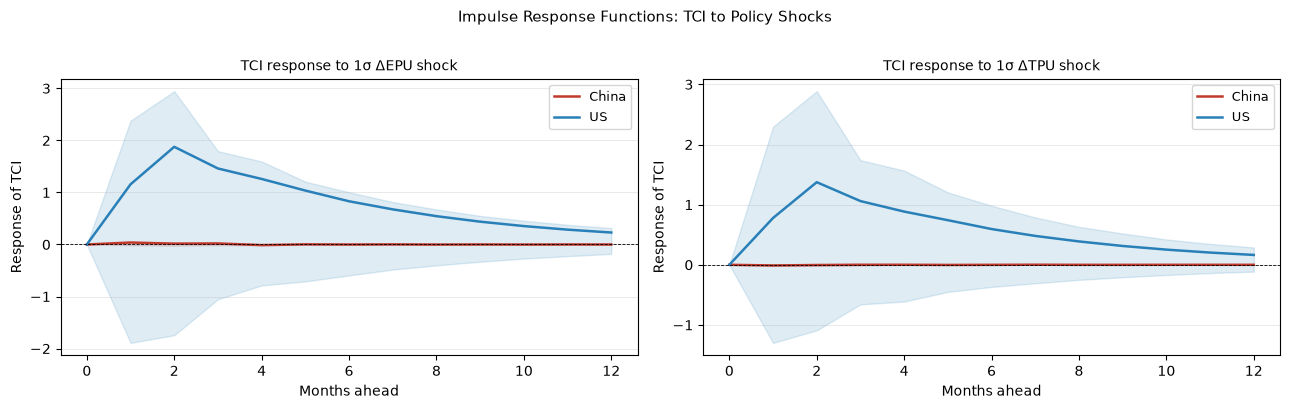

Saved: outputs/irf_overlay.png


In [ ]:
# ── 4.2: IRF overlay — China vs US response of TCI to policy shock ────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
titles    = ['TCI response to 1σ ΔEPU shock', 'TCI response to 1σ ΔTPU shock']
irf_keys  = [('irf_epu', 'ci_lo_epu', 'ci_hi_epu'), ('irf_tpu', 'ci_lo_tpu', 'ci_hi_tpu')]
colors    = {'China': '#c0392b', 'US': '#2980b9'}

for ax, title, (pt_col, lo_col, hi_col) in zip(axes, titles, irf_keys):
    for market_label, r1 in [('China', china_r1), ('US', us_r1)]:
        idf = r1['irf']
        h   = idf.index
        c   = colors[market_label]
        ax.plot(h, idf[pt_col], color=c, lw=1.8, label=market_label)
        ax.fill_between(h, idf[lo_col], idf[hi_col], color=c, alpha=0.15)
    ax.axhline(0, color='k', lw=0.6, ls='--')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Months ahead')
    ax.set_ylabel('Response of TCI')
    ax.legend(fontsize=9)
    ax.grid(axis='y', lw=0.4, alpha=0.5)

plt.suptitle('Impulse Response Functions: TCI to Policy Shocks', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'irf_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/irf_overlay.png')

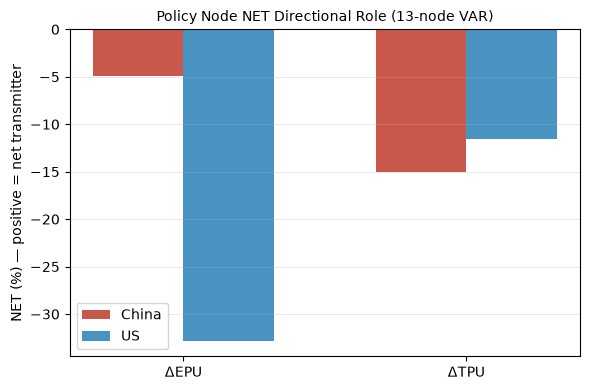

Saved: outputs/net_policy_nodes.png

NET table:


,ΔEPU,ΔTPU
China,-4.9015,-14.985
US,-32.8186,-11.558


In [ ]:
# ── 4.3: Policy node NET transmitter bar chart ────────────────────────────────
net_data = {}
for market_label, r2 in [('China', china_r2), ('US', us_r2)]:
    meas = r2['measures']
    for pol in ['ΔEPU', 'ΔTPU']:
        if pol in meas.index:
            net_data[(market_label, pol)] = meas.loc[pol, 'NET']
        else:
            net_data[(market_label, pol)] = np.nan

net_df = pd.Series(net_data).unstack(level=1)   # index=market, cols=policy

fig, ax = plt.subplots(figsize=(6, 4))
x       = np.arange(len(net_df.columns))
width   = 0.32
for i, (mkt, row) in enumerate(net_df.iterrows()):
    bars = ax.bar(x + i * width - width / 2, row.values, width, label=mkt,
                  color=['#c0392b', '#2980b9'][i], alpha=0.85)

ax.axhline(0, color='k', lw=0.7)
ax.set_xticks(x)
ax.set_xticklabels(net_df.columns, fontsize=10)
ax.set_ylabel('NET (%) — positive = net transmitter')
ax.set_title('Policy Node NET Directional Role (13-node VAR)', fontsize=10)
ax.legend()
ax.grid(axis='y', lw=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'net_policy_nodes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/net_policy_nodes.png')
print('\nNET table:')
display(net_df.round(4))

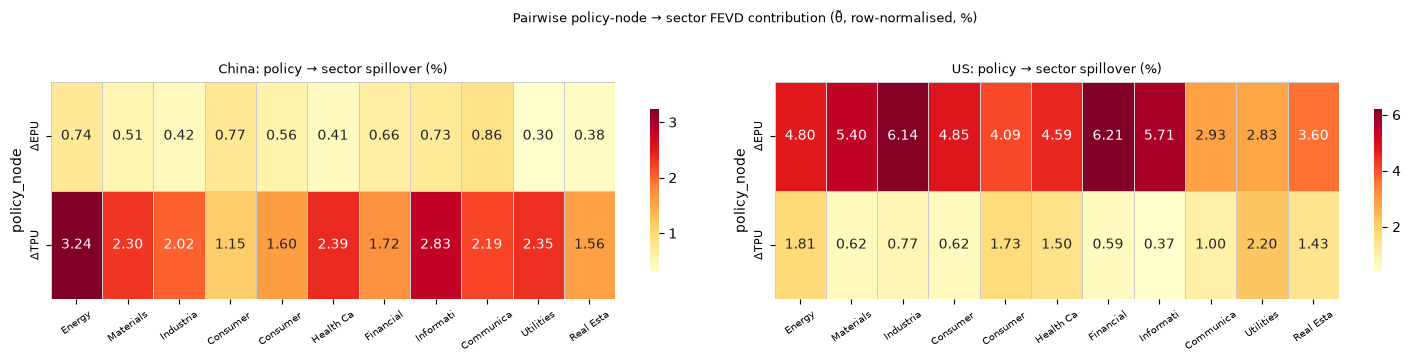

Saved: outputs/policy_sector_heatmap.png


In [ ]:
# ── 4.4: Policy-to-sector sensitivity heatmap (China vs US) ───────────────────
china_pts = china_r2['policy_to_sector']
us_pts    = us_r2['policy_to_sector']

# Align columns to GICS order where available
sec_order = [s for s in GICS_SECTORS if s in china_pts.columns]

fig, axes = plt.subplots(1, 2, figsize=(15, 3.5))
for ax, pts, title in zip(axes,
                           [china_pts[sec_order], us_pts[sec_order]],
                           ['China: policy → sector spillover (%)', 'US: policy → sector spillover (%)']):
    sns.heatmap(
        pts,
        ax=ax, annot=True, fmt='.2f', cmap='YlOrRd',
        linewidths=0.4, linecolor='#cccccc',
        cbar_kws={'shrink': 0.75},
        xticklabels=[s[:9] for s in sec_order],
    )
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=7, rotation=35)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Pairwise policy-node → sector FEVD contribution (θ̃, row-normalised, %)',
             fontsize=9, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'policy_sector_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/policy_sector_heatmap.png')

In [ ]:
# ── 4.5: Full 13-node directional table (both markets) ───────────────────────
print('\n══ China — 13-node directional measures (sorted by NET) ══')
print(f'Total Connectedness Index (Route2): {china_r2["tci_r2"]:.2f}%  |  VAR lag: p={china_r2["lag_order"]}')
display(china_r2['measures'].sort_values('NET', ascending=False).round(4))

print('\n══ US — 13-node directional measures (sorted by NET) ══')
print(f'Total Connectedness Index (Route2): {us_r2["tci_r2"]:.2f}%  |  VAR lag: p={us_r2["lag_order"]}')
display(us_r2['measures'].sort_values('NET', ascending=False).round(4))


══ China — 13-node directional measures (sorted by NET) ══
Total Connectedness Index (Route2): 79.14%  |  VAR lag: p=1


,TO,FROM,NET,OWN
Utilities,104.3338,82.6211,21.7127,17.3789
Industrials,97.3371,89.1601,8.1770,10.8399
Consumer Discretionary,95.1974,88.7575,6.4399,11.2425
Consumer Staples,91.6953,86.2633,5.4320,13.7367
Health Care,92.3516,87.0592,5.2924,12.9408
Materials,91.3232,87.9133,3.4099,12.0867
Financials,79.7678,79.0683,0.6996,20.9317
Information Technology,84.2600,88.2989,-4.0389,11.7011
ΔEPU,28.1972,33.0987,-4.9015,66.9013
Real Estate,80.1523,86.1672,-6.0148,13.8328



══ US — 13-node directional measures (sorted by NET) ══
Total Connectedness Index (Route2): 81.04%  |  VAR lag: p=2


,TO,FROM,NET,OWN
Industrials,100.6960,89.8387,10.8573,10.1613
Information Technology,98.9856,88.1782,10.8074,11.8218
Materials,99.5699,89.4927,10.0772,10.5073
Financials,96.6066,89.6140,6.9926,10.3860
Consumer Staples,96.4896,89.6695,6.8201,10.3305
Energy,94.7572,88.0604,6.6967,11.9396
Consumer Discretionary,93.9211,87.7276,6.1935,12.2724
Health Care,93.1762,88.9446,4.2316,11.0554
Real Estate,90.8332,89.1433,1.6899,10.8567
Communication Services,79.0654,88.3333,-9.2679,11.6667


In [ ]:
# ── 4.6: Stationarity summary (Stage A2) for both markets ────────────────────
for mkt in MARKETS:
    r1   = market_results[mkt]['r1']
    meta = r1['meta']
    adf  = meta['adf']
    df_adf = pd.DataFrame(adf).T.rename(columns={'stationary': 'Stationary', 'p': 'ADF p-value'})
    market_label = mkt.capitalize()
    print(f'\n══ {market_label} — ADF results ══')
    print(f'Route1 window: {meta["r1_window"][0].date()} → {meta["r1_window"][1].date()}  N={meta["r1_N"]} months')
    print(f'Route2 window: {meta["r2_window"][0].date()} → {meta["r2_window"][1].date()}  N={meta["r2_N"]} months')
    display(df_adf.round(6))


══ China — ADF results ══
Route1 window: 2012-07-01 → 2026-04-01  N=166 months
Route2 window: 2011-08-01 → 2026-04-01  N=177 months


,Stationary,ADF p-value
ΔEPU,True,0.0
ΔTPU,True,0.0
TCI,True,0.00005
Energy,True,0.000261
Materials,True,0.003267
Industrials,True,0.019364
Consumer Discretionary,True,0.001169
Consumer Staples,True,0.000667
Health Care,True,0.00003
Financials,True,0.002096



══ Us — ADF results ══
Route1 window: 2012-05-01 → 2026-05-01  N=169 months
Route2 window: 2011-08-01 → 2026-05-01  N=178 months


,Stationary,ADF p-value
ΔEPU,True,0.0
ΔTPU,True,0.0
TCI,True,0.005581
Energy,True,0.000136
Materials,True,0.0
Industrials,True,0.0
Consumer Discretionary,True,0.0
Consumer Staples,True,0.0
Health Care,True,0.0
Financials,True,0.0
